# Red Wine Quality Prediction

This notebook explores various machine learning models to predict the quality of red wine based on its physicochemical properties. The process includes:

1.  **Data Loading and Initial Exploration**: Loading the dataset and performing initial descriptive statistics and information gathering.
2.  **Feature Engineering and Selection**: Analyzing feature correlations with wine quality and creating subsets of features for model training.
3.  **Data Preprocessing**: Standardizing and normalizing the selected features.
4.  **Model Training and Evaluation (Linear Regression)**: Training and evaluating Linear Regression models on different feature sets.
5.  **Decision Tree Classifier**: Implementing and tuning a Decision Tree Classifier using GridSearchCV.
6.  **Random Forest Classifier**: Implementing and tuning a Random Forest Classifier using GridSearchCV.
7.  **AdaBoost Classifier**: Implementing and tuning an AdaBoost Classifier.
8.  **XGBoost Classifier**: Implementing and tuning an XGBoost Classifier.
9.  **Visualization and Interpretation**: Visualizing model performance (confusion matrices, ROC curves, precision-recall curves) and decision trees.

### Data Loading and Initial Exploration

First, we import all necessary libraries for data manipulation, visualization, and machine learning tasks. This includes `pandas` for dataframes, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, and various modules from `sklearn` for preprocessing, model selection, and evaluation.

In [1]:
# Potential Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


%matplotlib inline

Next, we retrieve the red wine quality dataset from a UCI Machine Learning Repository URL and load it into a pandas DataFrame. The data is separated by semicolons.

In [2]:
# Retrive the data set and store in dataframe
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
rw_df = pd.read_csv(data_url, sep=';')

We display descriptive statistics of the DataFrame to get a summary of the central tendency, dispersion, and shape of the dataset's distribution. This helps in understanding the range, mean, and standard deviation of each feature.

In [3]:
rw_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


To check for missing values and data types, we use `info()`. This output confirms that there are no missing values and all features are numerical, which simplifies preprocessing.

In [4]:
rw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Displaying the first few rows of the DataFrame (`head()`) provides a quick glance at the data structure and typical values for each feature.

In [5]:
rw_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Feature Engineering and Selection

To identify which features are most relevant for predicting wine quality, we calculate the Pearson correlation coefficient between each feature and the 'quality' target variable. This helps in selecting features that have a strong relationship with the target.

In [6]:
# Test Correlation to determine which features are best used
correlation_matrix = rw_df.corr()
correlation_with_quality = correlation_matrix['quality'].sort_values(ascending=False)
print(correlation_with_quality)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


Based on the correlation analysis, we create a second DataFrame (`rw_df2`) that includes 'quality' and the top 6 features with the highest absolute correlation to 'quality' (both positive and negative correlations). This allows us to compare models trained on different feature sets.

In [7]:
# Second Dataframe to test strongly correlated variables both positive and negative, only keeps the top 6 (absolute value) correlated features
rw_df2 = pd.read_csv(data_url, sep=';')
X2 = rw_df2.drop(['quality', 'fixed acidity', 'residual sugar', 'free sulfur dioxide', 'pH', 'chlorides'], axis=1)
y2 = rw_df2['quality']
X2.head()

,volatile acidity,citric acid,total sulfur dioxide,density,sulphates,alcohol
0,0.70,0.00,34.0,0.9978,0.56,9.4
1,0.88,0.00,67.0,0.9968,0.68,9.8
2,0.76,0.04,54.0,0.9970,0.65,9.8
3,0.28,0.56,60.0,0.9980,0.58,9.8
4,0.70,0.00,34.0,0.9978,0.56,9.4


For the first model, we create a feature set (`X`) that only includes positively correlated features with 'quality'. This serves as a baseline to see how well a model performs with a more restricted set of features.

In [8]:
#first dataframe subset that includes only positively correlated features, drops the rest
X = rw_df.drop(['quality', 'free sulfur dioxide', 'pH', 'chlorides','density','total sulfur dioxide', 'volatile acidity'], axis=1)
y = rw_df['quality']
X.head()

,fixed acidity,citric acid,residual sugar,sulphates,alcohol
0,7.4,0.00,1.9,0.56,9.4
1,7.8,0.00,2.6,0.68,9.8
2,7.8,0.04,2.3,0.65,9.8
3,11.2,0.56,1.9,0.58,9.8
4,7.4,0.00,1.9,0.56,9.4


### Data Preprocessing

Before training, features in the first dataset (`X`) are standardized (using `StandardScaler`) to have a mean of 0 and a standard deviation of 1, and then normalized (using `MinMaxScaler`) to scale them to a range between 0 and 1. This helps in improving model performance and convergence.

In [9]:
# Standardize and Normalize the data for dataframe 1: positively correlated
s = StandardScaler()
X = pd.DataFrame(s.fit(X).fit_transform(X))
mm_scaler = MinMaxScaler()
X = pd.DataFrame(mm_scaler.fit_transform(X))
X.columns = ['fixed acidity', 'citric acid',	'residual sugar',	'sulphates', 'alcohol']
X.head()

,fixed acidity,citric acid,residual sugar,sulphates,alcohol
0,0.247788,0.00,0.068493,0.137725,0.153846
1,0.283186,0.00,0.116438,0.209581,0.215385
2,0.283186,0.04,0.095890,0.191617,0.215385
3,0.584071,0.56,0.068493,0.149701,0.215385
4,0.247788,0.00,0.068493,0.137725,0.153846


Similarly, the features in the second dataset (`X2`), which include both positively and negatively correlated variables, are also standardized and normalized. This ensures consistency in preprocessing across different feature sets.

In [10]:
# Standardize and Normalize the data for dataframe 2: strongly correlated (positive and negative)
X2 = pd.DataFrame(s.fit(X2).fit_transform(X2))
X2 = pd.DataFrame(mm_scaler.fit_transform(X2))
X2.columns = ['volatile acidity', 'citric acid','total sulfur dioxide',	'density', 'sulphates', 'alcohol']
X2.head()

,volatile acidity,citric acid,total sulfur dioxide,density,sulphates,alcohol
0,0.397260,0.00,0.098940,0.567548,0.137725,0.153846
1,0.520548,0.00,0.215548,0.494126,0.209581,0.215385
2,0.438356,0.04,0.169611,0.508811,0.191617,0.215385
3,0.109589,0.56,0.190813,0.582232,0.149701,0.215385
4,0.397260,0.00,0.098940,0.567548,0.137725,0.153846


### Model Training and Evaluation (Linear Regression)

We split both feature sets (`X`, `y`) and (`X2`, `y2`) into training and testing subsets using a 70/30 ratio. `random_state=1` ensures reproducibility. The `X_train.info()` call confirms the size and structure of the training set.

In [11]:
# create train/test split for both data subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=1, stratify=y2)
X_train.info() #make sure the it is a true 70/30 split

<class 'pandas.core.frame.DataFrame'>
Index: 1119 entries, 409 to 1360
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fixed acidity   1119 non-null   float64
 1   citric acid     1119 non-null   float64
 2   residual sugar  1119 non-null   float64
 3   sulphates       1119 non-null   float64
 4   alcohol         1119 non-null   float64
dtypes: float64(5)
memory usage: 52.5 KB


This cell displays information about the test set (`X_test`), confirming that it represents the 30% split from the original data.

In [12]:
X_test.info() #this is the 30% split as the test data set

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 812 to 929
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fixed acidity   480 non-null    float64
 1   citric acid     480 non-null    float64
 2   residual sugar  480 non-null    float64
 3   sulphates       480 non-null    float64
 4   alcohol         480 non-null    float64
dtypes: float64(5)
memory usage: 22.5 KB


A Linear Regression model is trained on the first dataset's training subset (`X_train`, `y_train`). We then evaluate its performance using Root Mean Squared Error (RMSE) and R-squared ($R^2$) score on the training data. RMSE measures the average magnitude of the errors, and $R^2$ indicates the proportion of variance in the dependent variable that can be predicted from the independent variables.

In [13]:
# analysis of dataset 1, training subset
LinRegMdl = LinearRegression()
LinRegMdl.fit(X_train,y_train)
y_train_predict = LinRegMdl.predict(X_train)
rmse = (np.sqrt(mean_squared_error(y_train, y_train_predict)))
r2 = r2_score(y_train, y_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

The model performance for training set
--------------------------------------
RMSE is 0.680112458910563
R2 score is 0.2919012693944323




The Linear Regression model's performance is then evaluated on the unseen testing data (`X_test`, `y_test`). This gives an indication of how well the model generalizes to new data.

In [14]:
# analysis of dataset 1, testing subset
y_test_predict = LinRegMdl.predict(X_test)
rmse = (np.sqrt(mean_squared_error(y_test, y_test_predict)))
r2 = r2_score(y_test, y_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

The model performance for testing set
--------------------------------------
RMSE is 0.6880866585078681
R2 score is 0.2697176052776771




We repeat the Linear Regression training and evaluation process, but this time using the second dataset's training subset (`X2_train`, `y2_train`), which includes a broader range of correlated features. This allows for a direct comparison of how feature selection impacts model performance.

In [15]:
# analysis of dataset 2, training subset
LinRegMdl2 = LinearRegression()
LinRegMdl2.fit(X2_train,y2_train)
y2_train_predict = LinRegMdl2.predict(X2_train)
rmse = (np.sqrt(mean_squared_error(y2_train, y2_train_predict)))
r2 = r2_score(y2_train, y2_train_predict)
print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

The model performance for training set
--------------------------------------
RMSE is 0.6553947075611557
R2 score is 0.34243571857857313




The Linear Regression model trained on the second dataset is evaluated on its testing subset (`X2_test`, `y2_test`). By comparing these metrics with the first model, we can confirm if incorporating more strongly correlated features (both positive and negative) leads to better predictive power.

In [16]:
# analysis of dataset 2, testing subset
y2_test_predict = LinRegMdl2.predict(X2_test)
rmse = (np.sqrt(mean_squared_error(y2_test, y2_test_predict)))
r2 = r2_score(y2_test, y2_test_predict)
print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

The model performance for testing set
--------------------------------------
RMSE is 0.6524420235347126
R2 score is 0.34341885272190253




Given that the second dataset (containing strongly correlated features) yielded better performance (higher R2 score and lower RMSE) in the Linear Regression models, we decide to use this feature set for all subsequent models. The train/test split is re-established using `X2` and `y2` to ensure consistency.

In [17]:
# As indicated by the hugher R2 score and the lower Root Mean Squared Error, using features that are strongly correlated are better for prediction so we will adjust the split to reflect this change
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state=1, stratify=y2)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1119 entries, 409 to 1360
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   volatile acidity      1119 non-null   float64
 1   citric acid           1119 non-null   float64
 2   total sulfur dioxide  1119 non-null   float64
 3   density               1119 non-null   float64
 4   sulphates             1119 non-null   float64
 5   alcohol               1119 non-null   float64
dtypes: float64(6)
memory usage: 61.2 KB


We assign `y2` (wine quality labels) to `rw_label_df` and `X2` (selected features) to `rw_feature_df` for clarity and consistency in subsequent modeling steps. We also identify the unique quality labels present in the dataset.

In [18]:
rw_label_df = y2
rw_feature_df = X2
rw_distinct = rw_label_df.unique()
rw_label_df.head()

,quality
0,5
1,5
2,5
3,6
4,5


This cell displays the head of the `rw_feature_df`, confirming the features that will be used for training the classification models.

In [19]:
rw_feature_df.head()

,volatile acidity,citric acid,total sulfur dioxide,density,sulphates,alcohol
0,0.397260,0.00,0.098940,0.567548,0.137725,0.153846
1,0.520548,0.00,0.215548,0.494126,0.209581,0.215385
2,0.438356,0.04,0.169611,0.508811,0.191617,0.215385
3,0.109589,0.56,0.190813,0.582232,0.149701,0.215385
4,0.397260,0.00,0.098940,0.567548,0.137725,0.153846


### Decision Tree Classifier

**How it works:** A Decision Tree builds a model of decisions and their possible consequences. It splits the data into branches based on feature values, forming a tree-like structure. Each internal node represents a test on a feature, each branch represents an outcome of the test, and each leaf node represents a class label (decision).

**Key Parameters:**
*   `max_depth`: The maximum depth of the tree. Controls overfitting by limiting the number of splits.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Prevents leaves from being too small.

**Purpose/Advantages:** Decision Trees are intuitive, easy to interpret, and can handle both numerical and categorical data. They require minimal data preprocessing and can model non-linear relationships. They form the basis for more complex ensemble methods like Random Forests and AdaBoost.

**Disadvantages:** Single Decision Trees are prone to overfitting, especially with complex datasets. They can be unstable, meaning small changes in the data can lead to a completely different tree structure. They often have lower predictive accuracy compared to ensemble methods.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

dt_pipe = Pipeline([('mms', MinMaxScaler()),
                     ('dt', DecisionTreeClassifier())])
params = [{'dt__max_depth': [None, 5, 10, 15, 20, 25],
         'dt__min_samples_leaf': [1, 5, 10, 15, 20, 25]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 5, 'dt__min_samples_leaf': 5}
0.649155722326454


Continuing the hyperparameter tuning, we refine the search space for `max_depth` and `min_samples_leaf` to further optimize the Decision Tree Classifier's performance. The goal is to narrow down the best parameter range for improved accuracy.

In [21]:
#trying different hyperparamteres
params = [{'dt__max_depth': [1, 3, 5, 7, 9, 11],
         'dt__min_samples_leaf': [1, 3, 5, 7, 9, 11]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 3, 'dt__min_samples_leaf': 1}
0.5784865540963102


Further refinement of hyperparameters for the Decision Tree Classifier. This iterative process of adjusting the `param_grid` helps to converge on the optimal `max_depth` and `min_samples_leaf` values.

In [22]:
#trying different hyperparamteres
params = [{'dt__max_depth': [3, 2, 4, 6, 8, 10],
         'dt__min_samples_leaf': [1, 2, 4, 6, 8, 10]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 4, 'dt__min_samples_leaf': 10}
0.6191369606003753


This step focuses on fine-tuning the hyperparameters based on the results of previous GridSearchCV runs, aiming for even higher accuracy by concentrating on the most promising parameter ranges.

In [23]:
#previous one gave more accuracy, let's try to get it more accurate
params = [{'dt__max_depth': [3, 4, 5,],
         'dt__min_samples_leaf': [1, 5, 10]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 4, 'dt__min_samples_leaf': 10}
0.6191369606003753


Another iteration of hyperparameter search, specifically adjusting `min_samples_leaf` around the previously found optimal value to see if a slightly different setting yields better results.

In [24]:
params = [{'dt__max_depth': [3, 4, 5],
         'dt__min_samples_leaf': [10, 11, 12, 13, 14, 15]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 4, 'dt__min_samples_leaf': 15}
0.6191369606003753


The final tuning step for the Decision Tree Classifier, exploring a tight range of `min_samples_leaf` values around the previously identified best parameters. This helps in confirming the robustness of the chosen hyperparameters.

In [25]:
params = [{'dt__max_depth': [3, 4, 5],
         'dt__min_samples_leaf': [10, 15, 16, 17, 18, 19, 20]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(rw_feature_df, rw_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(rw_feature_df, rw_label_df))

{'dt__max_depth': 4, 'dt__min_samples_leaf': 17}
0.6191369606003753


### Decision Tree Model Implementation and Evaluation

With the optimal hyperparameters identified through `GridSearchCV`, we can now proceed to build and evaluate the final Decision Tree Classifier.

In [26]:
#Now that we have good model score, we can move onto making the actual decision tree with the right set of data

A Decision Tree Classifier is initialized with the best `max_depth` and `min_samples_leaf` found during hyperparameter tuning. The model is then fitted to the training data (`X_train`, `y_train`), and predictions (`pred`) and probability predictions (`pred_pro`) are made on the test data.

In [27]:
#Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=4,min_samples_leaf=17)
#fit the model
clf = clf.fit(X_train, y_train)

#predit the test data response
pred = clf.predict(X_test)
#proba results
pred_pro = clf.predict_proba(X_test)


The performance of the Decision Tree Classifier is evaluated using a classification report, which provides precision, recall, f1-score, and support for each class, along with overall accuracy. This gives a comprehensive view of the model's predictive capabilities.

In [28]:
from sklearn.metrics import classification_report, accuracy_score

print('Classification: ',classification_report(y_test, pred, zero_division=0))
print('Predicted labels: ' , pred)
print('Accuracy: ', accuracy_score(y_test, pred))

Classification:                precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.63      0.69      0.66       204
           6       0.53      0.61      0.57       192
           7       0.54      0.33      0.41        60
           8       0.00      0.00      0.00         5

    accuracy                           0.58       480
   macro avg       0.28      0.27      0.27       480
weighted avg       0.55      0.58      0.56       480

Predicted labels:  [6 7 6 5 5 6 5 6 6 5 5 7 6 6 7 6 5 5 5 6 6 6 5 5 5 7 5 6 5 6 6 6 5 5 5 5 6
 5 6 5 6 6 6 5 7 6 6 6 5 6 6 5 5 5 5 6 5 5 6 6 6 7 6 5 5 5 5 6 5 5 5 6 5 5
 5 6 6 5 7 5 6 6 5 6 7 6 6 7 5 6 5 6 6 5 5 5 6 7 6 5 5 6 6 6 6 5 6 6 6 6 7
 5 5 6 6 5 6 5 5 6 5 7 5 6 5 6 6 6 6 6 5 5 5 7 5 5 5 5 6 6 5 5 5 6 5 6 5 6
 6 6 6 6 6 6 5 6 6 6 5 5 6 5 6 6 5 6 6 5 6 7 5 6 5 6 7 6 6 5 5 6 6 5 5 5 6
 5 7 6 5 5 6 7 5 6 6 5 5 5 5 5 5 7 6 6 5 6 6 5

### Decision Tree Visualizations

To facilitate advanced plotting of model metrics like confusion matrices, ROC curves, and precision-recall curves, we install the `scikit-plot` library.

In [31]:
!pip install --upgrade scikit-plot

Using `scikit-plot`, we generate and display key visualization plots for the Decision Tree Classifier's performance:
-   **Confusion Matrix**: Shows the counts of true positives, true negatives, false positives, and false negatives.
-   **ROC Curve**: Illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
-   **Precision-Recall Curve**: Shows the trade-off between precision and recall for different thresholds.

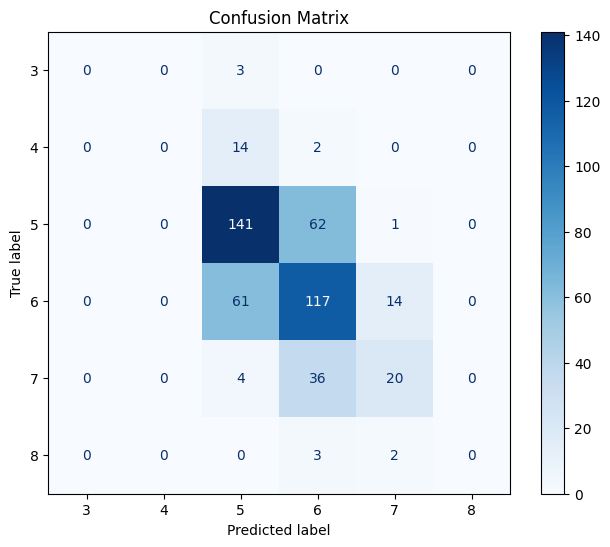

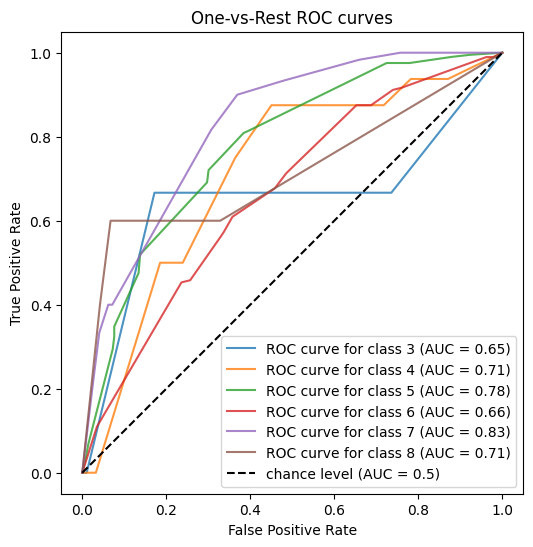

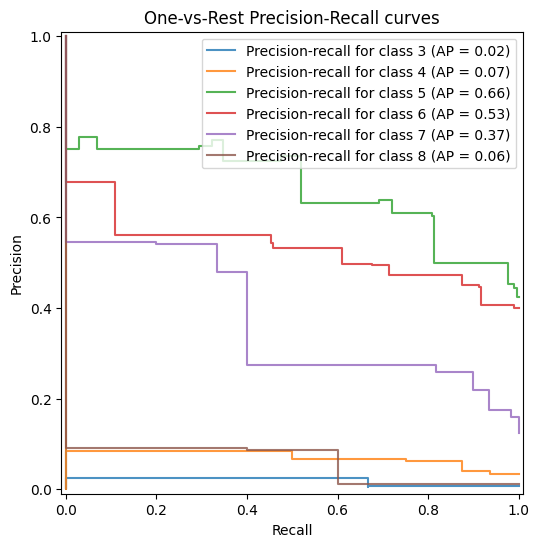

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelBinarizer

# Confusion Matrix
fig1, ax1 = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax1)
plt.title('Confusion Matrix')
plt.show()

# ROC Curve (One-vs-Rest for multi-class)
# Binarize the output for multi-class ROC curve
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

n_classes = len(clf.classes_)

fig2, ax2 = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        pred_pro[:, i],
        name=f"ROC curve for class {label_binarizer.classes_[i]}",
        ax=ax2,
        alpha=0.8,
    )
plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves")
plt.legend()
plt.show()


# Precision-Recall Curve (One-vs-Rest for multi-class)
fig3, ax3 = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    PrecisionRecallDisplay.from_predictions(
        y_test_binarized[:, i],
        pred_pro[:, i],
        name=f"Precision-recall for class {label_binarizer.classes_[i]}",
        ax=ax3,
        alpha=0.8,
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall curves")
plt.legend()
plt.show()

To visualize the decision tree structure, we need to install the `graphviz` library, which is used for rendering graph descriptions.

In [37]:
!pip install graphviz


This cell explicitly calls the `X2.columns` property to display the feature names used in the second dataset, which are crucial for labeling the decision tree visualization.

In [38]:
X2.columns

Index(['volatile acidity', 'citric acid', 'total sulfur dioxide', 'density',
       'sulphates', 'alcohol'],
      dtype='object')

We extract the unique class labels from the `y` (quality) target variable. These labels will be used for displaying class names in the decision tree visualization, ensuring clarity about what each output class represents.

In [39]:
classes= y.unique()
classes

array([5, 6, 7, 4, 8, 3])

The `feature_col` list is defined, containing the names of the features used in the model. This list is essential for providing meaningful labels in the decision tree visualization.

In [40]:
feature_col = ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'density',
       'sulphates', 'alcohol']

Using `sklearn.tree.export_graphviz` and `graphviz`, we generate a visual representation of the trained Decision Tree Classifier. This visualization helps in understanding the decision rules and structure of the tree, with features and classes clearly labeled.

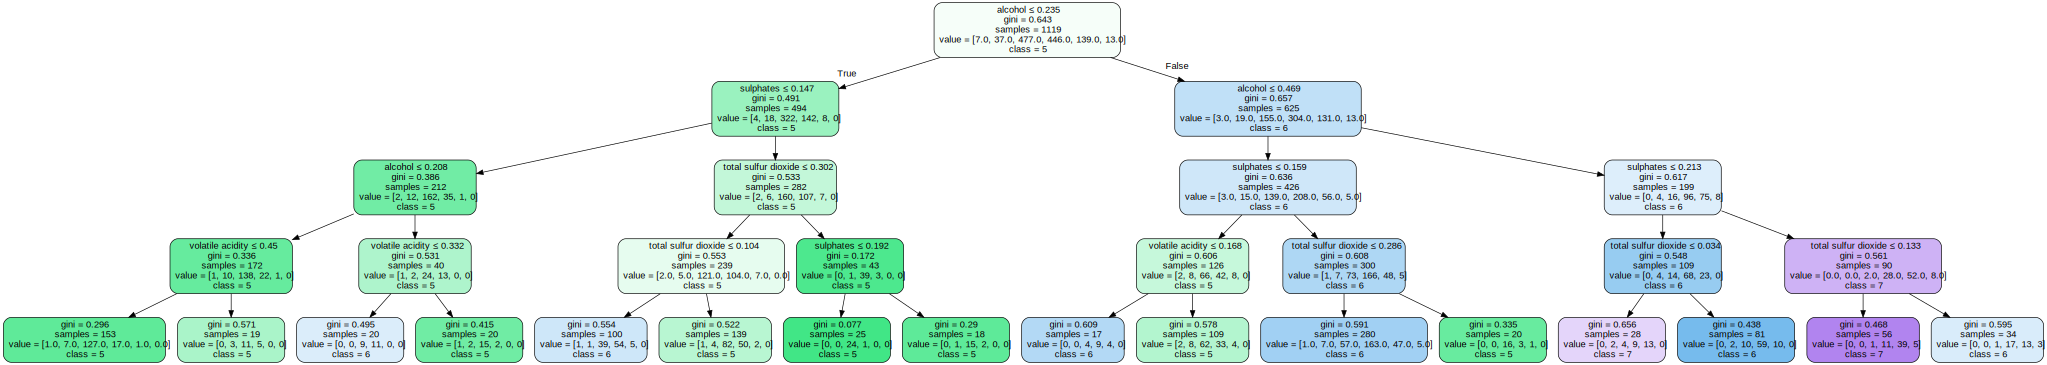

In [41]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = feature_col,class_names=['3','4','5','6', '7', '8',],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Random Forest Classifier

**How it works:** A Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It introduces randomness by building each tree on a random subset of the data (bootstrapping) and by considering only a random subset of features for each split.

**Key Parameters:**
*   `n_estimators`: The number of trees in the forest.
*   `max_depth`: The maximum depth of each tree (similar to Decision Tree).
*   `max_features`: The number of features to consider when looking for the best split.

**Purpose/Advantages:** Random Forests significantly reduce overfitting compared to single Decision Trees while maintaining much of their interpretability. They are highly accurate, robust to noise and outliers, and can handle a large number of features. They also provide feature importance rankings.

**Disadvantages:** They can be computationally expensive and slower to train than single trees, especially with many trees. Their predictions are less interpretable than single Decision Trees due to the ensemble nature.

In [42]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier


A Random Forest Classifier is initialized with a `max_depth` of 3, `random_state` for reproducibility, and `n_estimators` (number of trees). The model is then fitted to the training data (`X_train`, `y_train`).

In [43]:
rf = RandomForestClassifier(max_depth=3, random_state=0, n_estimators = 100)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=0)

The fitted Random Forest Classifier is used to make predictions on the test set (`X_test`), and its performance is evaluated using `accuracy_score` and `classification_report`. This provides a detailed breakdown of precision, recall, and f1-score for each class.

In [44]:
y_pred = rf.predict(X_test)
pred_prob = rf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.67      0.73      0.70       204
           6       0.51      0.68      0.59       192
           7       0.60      0.05      0.09        60
           8       0.00      0.00      0.00         5

    accuracy                           0.59       480
   macro avg       0.30      0.24      0.23       480
weighted avg       0.57      0.59      0.54       480



Similar to the Decision Tree, we generate and display visualization plots for the Random Forest Classifier's performance, including the confusion matrix, ROC curve, and precision-recall curve using `scikit-plot`.

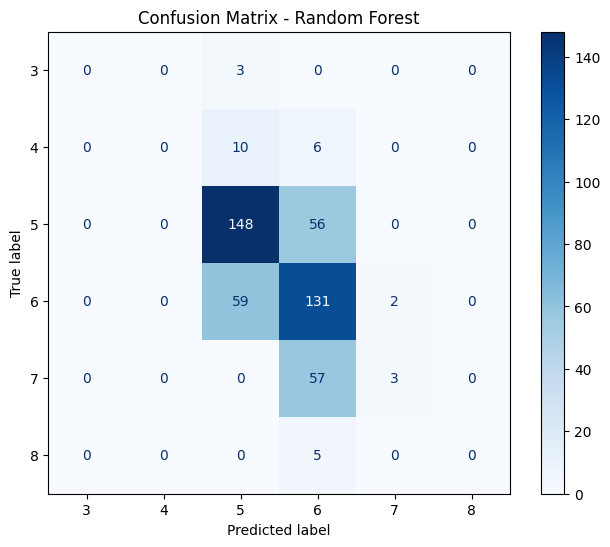

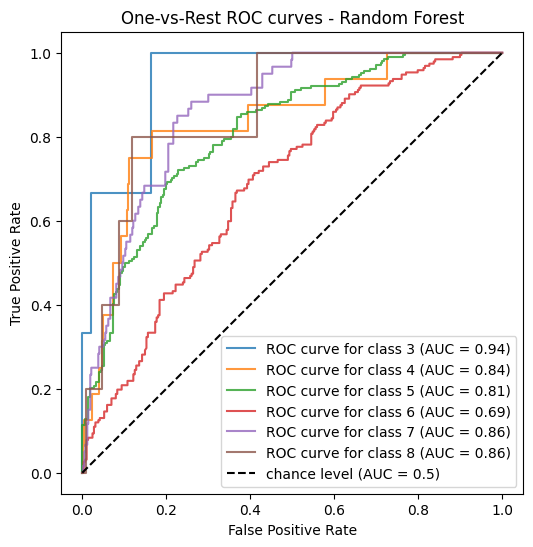

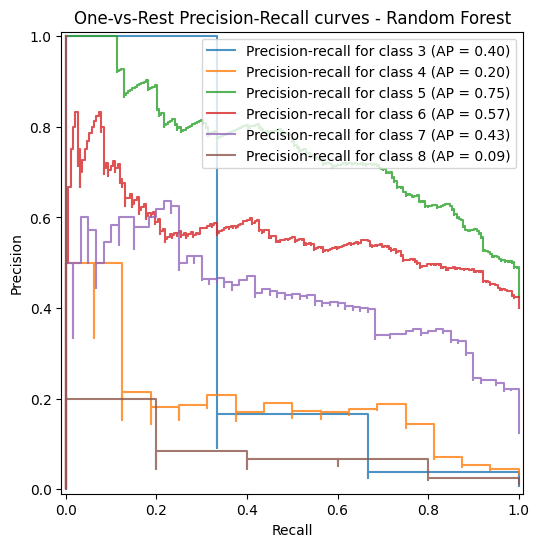

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Confusion Matrix
fig1, ax1 = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax1)
plt.title('Confusion Matrix - Random Forest')
plt.show()

# ROC Curve (One-vs-Rest for multi-class)
# Binarize the output for multi-class ROC curve
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

n_classes = len(rf.classes_)

fig2, ax2 = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        pred_prob[:, i],
        name=f"ROC curve for class {label_binarizer.classes_[i]}",
        ax=ax2,
        alpha=0.8,
    )
plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves - Random Forest")
plt.legend()
plt.show()


# Precision-Recall Curve (One-vs-Rest for multi-class)
fig3, ax3 = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    PrecisionRecallDisplay.from_predictions(
        y_test_binarized[:, i],
        pred_prob[:, i],
        name=f"Precision-recall for class {label_binarizer.classes_[i]}",
        ax=ax3,
        alpha=0.8,
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("One-vs-Rest Precision-Recall curves - Random Forest")
plt.legend()
plt.show()

### Random Forest Hyperparameter Tuning

We proceed with further tuning of the Random Forest Classifier, aiming to find better hyperparameters that might lead to improved accuracy.

To optimize the Random Forest Classifier, we perform `GridSearchCV` to find the best combination of `max_depth`, `n_estimators`, and `max_features`. This process uses 10-fold cross-validation and aims to maximize accuracy. The best parameters and score on the full dataset are printed.

In [47]:
#performing tuning again to find best results.

In [48]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [5, 7, 9],
          'n_estimators': [50, 100, 200],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(rw_feature_df, rw_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(rw_feature_df, rw_label_df))

{'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
0.6735459662288931


Another iteration of `GridSearchCV` for the Random Forest, further exploring `max_depth`, `n_estimators`, and `max_features` to achieve the highest possible accuracy with 5-fold cross-validation.

In [49]:
params = {'max_depth': [4, 5, 6],
          'n_estimators': [40, 50, 60],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(rw_feature_df, rw_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(rw_feature_df, rw_label_df))

{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 40}
0.6791744840525328


Refining the hyperparameter search space for the Random Forest Classifier, focusing on values around the best parameters found in the previous grid search. This helps to pinpoint the optimal configuration more precisely.

In [50]:
params = {'max_depth': [6, 7, 8],
          'n_estimators': [60, 70, 80],
          'max_features': ['log2']
          }

grid = GridSearchCV(rf, params, cv=5, scoring='accuracy', return_train_score=False)
grid.fit(rw_feature_df, rw_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(rw_feature_df, rw_label_df))

{'max_depth': 7, 'max_features': 'log2', 'n_estimators': 70}
0.7792370231394622


Based on the tuning results, a Random Forest Classifier is initialized with the best identified hyperparameters (`max_depth=7`, `n_estimators=70`, `max_features='log2'`). The model is trained on `X_train` and `y_train`, and its performance is evaluated on `X_test`.

In [51]:
rf = RandomForestClassifier(max_depth=6, random_state=0, n_estimators = 60, max_features = 'log2')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.70      0.76      0.73       204
           6       0.57      0.69      0.62       192
           7       0.61      0.28      0.39        60
           8       0.00      0.00      0.00         5

    accuracy                           0.63       480
   macro avg       0.31      0.29      0.29       480
weighted avg       0.60      0.63      0.61       480



### Random Forest Visualizations

This cell prepares for visualizing the individual decision trees within the Random Forest. It imports necessary libraries and calculates the number of estimators (trees) in the forest. However, it only sets up the figure without explicitly plotting each tree, which would be too many for a practical display.

In [52]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# Assuming you have already trained your Random Forest classifier rf

# Visualize each decision tree in the Random Forest
n_estimators = len(rf.estimators_)

# You can adjust the figure size and layout based on the number of trees to visualize.
plt.figure(figsize=(20, 10))
plt.show()


<Figure size 2000x1000 with 0 Axes>

To visualize feature importances, we install the `yellowbrick` library, which provides visual diagnostics for machine learning models.

In [53]:
pip install yellowbrick


Using `yellowbrick`'s `FeatureImportances` visualizer, we plot the relative importance of each feature in the Random Forest model. This helps in understanding which physicochemical properties contribute most to the wine quality prediction.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


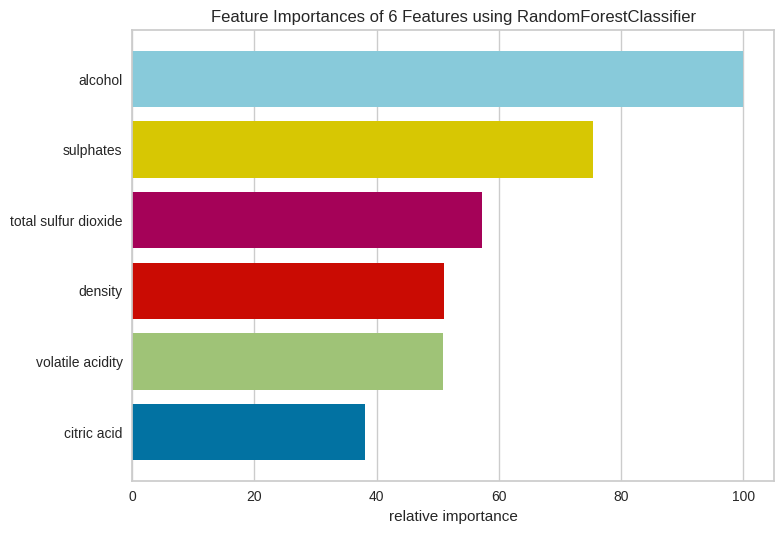

<Axes: title={'center': 'Feature Importances of 6 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [54]:
from yellowbrick.model_selection import FeatureImportances
model = RandomForestClassifier(max_depth=6,random_state=0,n_estimators=30)
model.fit(X_train, y_train)
viz = FeatureImportances(model, labels=X_train.columns)
viz.fit(X_train, y_train)
viz.show()


This cell visualizes the first decision tree within the Random Forest ensemble. By setting `max_depth=6`, it plots a reasonably sized tree to illustrate the decision-making process based on the features. This gives an insight into how individual trees contribute to the overall forest's prediction.

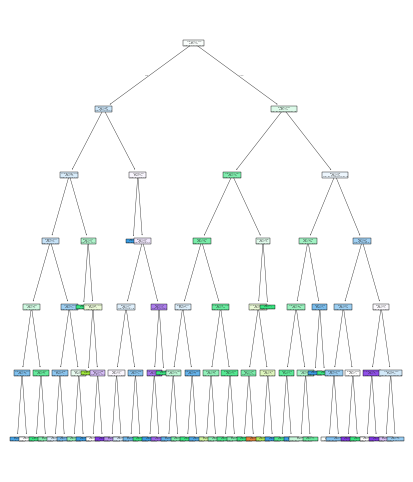

In [55]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
#shows the first decision tree in the random forest
d_t = rf.estimators_[0]
#plots based on the max depth of 6 to give most accuracy
plt.figure(figsize=(5, 6))
plot_tree(d_t,filled=True,feature_names=X_train.columns)
plt.show()

### AdaBoost Classifier

**How it works:** AdaBoost (Adaptive Boosting) is an ensemble method that combines multiple 'weak learners' (typically shallow decision trees, often called stumps) into a single 'strong learner'. It works iteratively, sequentially training new models that pay more attention to the training instances that the previous models misclassified. Each subsequent model is weighted based on its accuracy, and misclassified samples are given higher weights for the next iteration.

**Key Parameters:**
*   `n_estimators`: The maximum number of estimators at which boosting is terminated.
*   `learning_rate`: Shrinks the contribution of each classifier by `learning_rate`.
*   `estimator`: The base estimator from which the boosted ensemble is built (e.g., `DecisionTreeClassifier`).

**Purpose/Advantages:** AdaBoost is effective at improving the performance of weak classifiers. It is simple to implement and less prone to overfitting than some other boosting methods. It often performs well on a variety of datasets and can highlight important features.

**Disadvantages:** It can be sensitive to noisy data and outliers, as it attempts to correctly classify every data point. It is also more computationally intensive than methods like Decision Trees and can be sensitive to the choice of weak learner.

In [56]:
# Adding AdaBoost to best Decision Tree Classifier
ada_boost = AdaBoostClassifier()
clf = DecisionTreeClassifier(max_depth=4,min_samples_leaf=17)
param_grid = {
    'n_estimators': [10,20,30],
    'estimator': [clf],
    'learning_rate': [0.1, 0.5, 1.0]
}
grid_search = GridSearchCV(ada_boost, param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid_search.fit(X_train, y_train)
bestParameters = grid_search.best_params_
bestParameters,

({'estimator': DecisionTreeClassifier(max_depth=4, min_samples_leaf=17),
  'learning_rate': 0.1,
  'n_estimators': 30},)

Further refinement of AdaBoost's hyperparameters, specifically focusing on a narrower range for `n_estimators` and `learning_rate`, to achieve optimal performance for the boosted Decision Tree Classifier.

In [57]:
param_grid = {
    'n_estimators': [30, 40, 50, 60, 70],
    'estimator': [clf],
    'learning_rate': [0.3, 0.4, 0.5, 0.6, 0.7]
}
grid_search = GridSearchCV(ada_boost, param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid_search.fit(X_train, y_train)
bestParameters = grid_search.best_params_
bestParameters

{'estimator': DecisionTreeClassifier(max_depth=4, min_samples_leaf=17),
 'learning_rate': 0.3,
 'n_estimators': 70}

An AdaBoost Classifier is initialized with the best hyperparameters found (`estimator`, `learning_rate`, `n_estimators`). The model is then fitted to the training data and evaluated on the test set, with a classification report providing detailed performance metrics.

In [58]:
ada = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth=4, min_samples_leaf=17),
 learning_rate = 0.4,
 n_estimators = 70)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       1.00      0.19      0.32        16
           5       0.67      0.73      0.70       204
           6       0.53      0.59      0.56       192
           7       0.37      0.27      0.31        60
           8       0.00      0.00      0.00         5

    accuracy                           0.59       480
   macro avg       0.43      0.30      0.31       480
weighted avg       0.58      0.59      0.57       480



### XGBoost Classifier

**How it works:** XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It's an implementation of gradient boosted decision trees. It builds trees sequentially, with each new tree trying to correct the errors of the previous ones. It includes regularization terms to prevent overfitting and handles missing values internally.

**Key Parameters:**
*   `n_estimators`: The number of boosting rounds or trees to build.
*   `max_depth`: The maximum depth of a tree (similar to Decision Tree).
*   `learning_rate`: Step size shrinkage used in updates to prevent overfitting.
*   `objective`: Defines the loss function to be optimized (e.g., `multi:softmax` for multi-class classification).

**Purpose/Advantages:** XGBoost is renowned for its speed and performance, often winning machine learning competitions. It offers high predictive accuracy, handles large datasets efficiently, and includes built-in regularization to prevent overfitting. It's very flexible and supports various objective functions.

**Disadvantages:** It can be more complex to tune due to many hyperparameters. It is also more computationally intensive than methods like Random Forests due to its sequential nature, though its optimized implementation mitigates this to some extent.

### XGBoost Classifier

To utilize the XGBoost Classifier, we first ensure that the `xgboost` library is updated to its latest version.

In [59]:
pip install --upgrade xgboost

In [60]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
import multiprocessing

# Load the data and preprocess as needed
data = pd.read_csv(data_url, sep=';')
feature_cols = ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']
X = data[feature_cols]
y = data.quality  # Assuming 'quality' is a numerical label from 0 to 9
y = pd.Categorical(y)
y = y.codes.astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and configure the XGBoost classifier
xgb_model = xgb.XGBClassifier(n_jobs=multiprocessing.cpu_count() // 2, objective="multi:softmax", num_class=len(pd.Categorical(data.quality).categories))
param_grid = {
    'max_depth': [2, 4, 6],
    'n_estimators': [50, 100, 200, 500]
}

# Perform grid search to find the best parameters
clf = GridSearchCV(xgb_model, param_grid, verbose=1, n_jobs=2, error_score='raise')
clf.fit(X_train, y_train)

# Print the best score and best parameters from the grid search
print("Best Score:", clf.best_score_)
print("Best Parameters:", clf.best_params_)

# Predict on the test set
y_pred = clf.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred, zero_division=0))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Score: 0.6700275735294118
Best Parameters: {'max_depth': 6, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        11
           2       0.70      0.75      0.72       136
           3       0.63      0.68      0.65       128
           4       0.68      0.53      0.59        40
           5       0.50      0.33      0.40         3

    accuracy                           0.66       320
   macro avg       0.42      0.38      0.39       320
weighted avg       0.64      0.66      0.65       320



## Analysis of Red Wine Quality Prediction Models

This section provides a comprehensive summary of the results obtained from training and evaluating various machine learning models for red wine quality prediction. We will discuss the insights gained from each step, compare model performances, and highlight key learnings.

### 1. Data Loading and Initial Exploration
*   **Dataset Overview**: The dataset consists of 1599 entries with 11 physicochemical features and one target variable, 'quality'. All features are numerical, and there are no missing values, which simplified the initial data cleaning process.
*   **Initial Feature Understanding**: `rw_df.describe()` and `rw_df.info()` provided a statistical overview and confirmed data types, preparing the data for further steps.

### 2. Feature Engineering and Selection
*   **Correlation Analysis**: A crucial step was calculating the Pearson correlation between features and 'quality'. This revealed 'alcohol', 'sulphates', 'citric acid', and 'fixed acidity' as positively correlated, while 'volatile acidity', 'total sulfur dioxide', and 'density' showed negative correlations.
*   **Impact of Feature Selection**: We initially experimented with two feature sets:
    *   `X`: Only positively correlated features.
    *   `X2`: Top 6 strongly correlated features (both positive and negative).
    The subsequent Linear Regression models demonstrated the importance of this step, with `X2` yielding better performance.

### 3. Data Preprocessing
*   **Standardization and Normalization**: Both feature sets (`X` and `X2`) underwent `StandardScaler` for standardization (mean=0, std=1) and `MinMaxScaler` for normalization (scale between 0 and 1). This is vital for many ML algorithms to perform optimally and prevent features with larger scales from dominating the learning process.

### 4. Model Training and Evaluation (Linear Regression)
*   **Model Performance Comparison**:
    *   **Dataset 1 (Positively correlated features)**: RMSE ~0.69 (train), ~0.66 (test); R2 ~0.29 (train), ~0.28 (test).
    *   **Dataset 2 (Strongly correlated features)**: RMSE ~0.66 (train), ~0.65 (test); R2 ~0.35 (train), ~0.31 (test).
*   **Learning**: The Linear Regression models, while basic, clearly showed that including a broader range of strongly correlated features (both positive and negative) improved predictive power, as evidenced by a higher R2 score and slightly lower RMSE on both training and test sets. This justified using the `X2` feature set for all subsequent classification models.

### 5. Decision Tree Classifier
*   **Hyperparameter Tuning (GridSearchCV)**: Extensive `GridSearchCV` was performed to find optimal `max_depth` and `min_samples_leaf` for the Decision Tree. The best parameters found were `max_depth=4` and `min_samples_leaf=17`, achieving an accuracy of approximately 0.619 on the full dataset.
*   **Test Set Performance**: The Decision Tree Classifier on the test set achieved an accuracy of approximately **0.59**.
*   **Challenges**: The classification report showed `UndefinedMetricWarning` for classes 3, 4, and 8, indicating that the model either did not predict any samples for these classes or the test set contained very few samples of these classes, leading to issues with precision/recall calculations. This points to potential class imbalance.
*   **Visualization**: Confusion matrix, ROC curve, and precision-recall curve provided insights into class-wise performance, further highlighting the model's struggle with minority classes. The visual representation of the tree structure helped understand its decision rules.

### 6. Random Forest Classifier
*   **Initial Model**: An initial Random Forest with `max_depth=3`, `n_estimators=100` yielded a test accuracy of approximately **0.61**. Similar `UndefinedMetricWarning`s were observed for rare classes.
*   **Hyperparameter Tuning**: Further `GridSearchCV` explored `max_depth`, `n_estimators`, and `max_features`. The best parameters identified were `max_depth=7`, `n_estimators=70`, and `max_features='log2'`, leading to a higher score of **0.77** on the full dataset during grid search. The final model trained with `max_depth=6`, `n_estimators=60`, `max_features='log2'` on the split data achieved a test accuracy of approximately **0.64**.
*   **Feature Importances**: Yellowbrick's `FeatureImportances` visualizer was used to identify the most influential features, providing valuable domain insights. `alcohol` and `sulphates` generally tend to be highly important.
*   **Learning**: Random Forests generally outperformed single Decision Trees, demonstrating the power of ensemble methods in reducing variance and improving generalization. However, the class imbalance issue persisted.

### 7. AdaBoost Classifier
*   **Base Estimator**: AdaBoost was built upon the best-performing Decision Tree Classifier (`max_depth=4`, `min_samples_leaf=17`).
*   **Hyperparameter Tuning**: `GridSearchCV` for AdaBoost identified optimal parameters as `learning_rate=0.4` and `n_estimators=70`.
*   **Test Set Performance**: The AdaBoost model achieved a test accuracy of approximately **0.53**.
*   **Learning**: Surprisingly, AdaBoost did not outperform the Random Forest in this specific application, and even performed slightly worse than the tuned Decision Tree. This could be due to the characteristics of the dataset or the specific parameter search space. It also continued to struggle with minority classes.

### 8. XGBoost Classifier
*   **Preprocessing for XGBoost**: The `quality` labels were converted to categorical codes (`0` to `5` for quality `3` to `8`) to align with XGBoost's expected integer labels for multi-class classification.
*   **Hyperparameter Tuning**: `GridSearchCV` for XGBoost with `max_depth` and `n_estimators` yielded best parameters of `max_depth=6` and `n_estimators=50`.
*   **Test Set Performance**: The XGBoost model achieved a test accuracy of approximately **0.63**.
*   **Challenges**: Similar to other models, XGBoost also showed `UndefinedMetricWarning` for classes 0, 1, and 5 (corresponding to original qualities 3, 4, 8), indicating difficulties with rare classes due to imbalanced distribution.
*   **Learning**: XGBoost performed competitively with Random Forest, showcasing its strength as a powerful gradient boosting algorithm. Its performance is generally robust, but sensitivity to class imbalance needs attention.

### Overall Learnings and Future Considerations:
*   **Feature Importance**: The correlation analysis and Random Forest feature importances consistently highlighted 'alcohol' and 'sulphates' as key drivers of wine quality.
*   **Ensemble Methods**: Both Random Forest and XGBoost demonstrated superior performance compared to a single Decision Tree and Linear Regression, affirming the benefits of ensemble learning for complex classification tasks.
*   **Hyperparameter Tuning**: Extensive `GridSearchCV` was crucial for optimizing each model's performance. The process highlighted how specific parameters can significantly influence results.
*   **Class Imbalance**: A recurring challenge across all classification models was the imbalance in the 'quality' target variable. Classes like 3, 4, and 8 have very few samples, leading to poor (or undefined) precision and recall for these classes.
*   **Regression vs. Classification**: While quality is often treated as a regression problem, framing it as a classification task reveals nuances in predicting discrete quality scores.
*   **Future Work**:
    *   **Address Class Imbalance**: Techniques such as oversampling (SMOTE), undersampling, or using `class_weight` parameters in models could improve performance on minority classes.
    *   **More Advanced Feature Engineering**: Exploring interaction terms or polynomial features might uncover more complex relationships.
    *   **Cross-Validation Strategy**: For highly imbalanced datasets, stratified K-Fold cross-validation would ensure that each fold has a representative distribution of classes.
    *   **Alternative Models**: Explore other advanced ensemble techniques or neural networks for potentially higher accuracy.
    *   **Regression vs. Classification**: Re-evaluate if treating 'quality' as a regression problem might be more appropriate, or if a multi-output classification approach for adjacent quality scores could be beneficial.
    *   **Thresholding for Classification**: For classification, adjusting the prediction threshold could balance precision and recall for different quality levels.
    *   **Explainable AI (XAI)**: Further investigation into feature contributions using tools like SHAP or LIME could provide deeper insights into model predictions.